In [1]:
# CELL 1: IMPORTS

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import time
import joblib
import os
warnings.filterwarnings('ignore')

# ML Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

# Evaluation
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    average_precision_score, precision_recall_curve,
    f1_score, precision_score, recall_score,
    matthews_corrcoef, balanced_accuracy_score
)
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV

# Explainability
import shap

os.makedirs('../results', exist_ok=True)
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')

print(' All libraries loaded!')
print(f'XGBoost version: {xgb.__version__}')

 All libraries loaded!
XGBoost version: 3.2.0


In [2]:
# CELL 2: LOAD DATA

X_train = np.load('../data/X_train.npy')
y_train = np.load('../data/y_train.npy')
X_val   = np.load('../data/X_val.npy')
y_val   = np.load('../data/y_val.npy')
X_test  = np.load('../data/X_test.npy')
y_test  = np.load('../data/y_test.npy')

feature_names = pd.read_csv('../data/feature_names.csv')['feature'].tolist()

print('=== Data Loaded ===')
print(f'X_train: {X_train.shape} | Fraud: {y_train.sum():,} ({y_train.mean()*100:.1f}%) [SMOTE applied]')
print(f'X_val:   {X_val.shape}   | Fraud: {y_val.sum()} ({y_val.mean()*100:.3f}%)')
print(f'X_test:  {X_test.shape}  | Fraud: {y_test.sum()} ({y_test.mean()*100:.3f}%)')
print(f'Features: {len(feature_names)} → {feature_names}')

=== Data Loaded ===
X_train: (200157, 32) | Fraud: 18,196 (9.1%) [SMOTE applied]
X_val:   (45569, 32)   | Fraud: 79 (0.173%)
X_test:  (56962, 32)  | Fraud: 98 (0.172%)
Features: 32 → ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Hour_sin', 'Hour_cos', 'Log_Amount']


In [3]:
# CELL 3: EVALUATION HELPER FUNCTIONS

def evaluate_model(model, X, y, model_name, threshold=0.5, verbose=True):
    """
    Comprehensive model evaluation for fraud detection.
    Returns dictionary of all metrics.
    """
    # Get probabilities
    y_prob = model.predict_proba(X)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    # Core metrics
    auc_roc   = roc_auc_score(y, y_prob)
    avg_prec  = average_precision_score(y, y_prob)
    precision = precision_score(y, y_pred, zero_division=0)
    recall    = recall_score(y, y_pred, zero_division=0)
    f1        = f1_score(y, y_pred, zero_division=0)
    mcc       = matthews_corrcoef(y, y_pred)
    bal_acc   = balanced_accuracy_score(y, y_pred)

    # Confusion matrix values
    cm = confusion_matrix(y, y_pred)
    tn, fp, fn, tp = cm.ravel()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0

    if verbose:
        print(f'\n{"═"*55}')
        print(f'   {model_name} (threshold={threshold:.2f})')
        print(f'{"═"*55}')
        print(f'  AUC-ROC:            {auc_roc:.4f}')
        print(f'  Average Precision:  {avg_prec:.4f}')
        print(f'  Precision:          {precision:.4f}')
        print(f'  Recall (Sensitivity):{recall:.4f}')
        print(f'  F1-Score:           {f1:.4f}')
        print(f'  MCC:                {mcc:.4f}')
        print(f'  Balanced Accuracy:  {bal_acc:.4f}')
        print(f'  False Positive Rate:{fpr:.4f}')
        print(f'  False Negative Rate:{fnr:.4f}')
        print(f'  Confusion Matrix:')
        print(f'    TN={tn:,}  FP={fp}')
        print(f'    FN={fn}   TP={tp}')
        print(f'\n  Classification Report:')
        print(classification_report(y, y_pred,
              target_names=['Legitimate', 'Fraud']))

    return {
        'model_name': model_name,
        'auc_roc': auc_roc, 'avg_precision': avg_prec,
        'precision': precision, 'recall': recall,
        'f1': f1, 'mcc': mcc, 'balanced_accuracy': bal_acc,
        'fpr': fpr, 'fnr': fnr,
        'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp,
        'y_prob': y_prob, 'y_pred': y_pred, 'threshold': threshold
    }

results = {}  # Store all model results
print(' Evaluation functions ready!')

 Evaluation functions ready!


In [4]:
# CELL 4: LOGISTIC REGRESSION

print('   Model 1: Logistic Regression (Baseline)')
print('   Why: Simple, interpretable, fast — good baseline')
print('   Algorithm: Logistic function with L2 regularization')
print('-' * 50)

start = time.time()
lr_model = LogisticRegression(
    C=0.01,                   # Regularization (lower = stronger)
    max_iter=1000,             # Sufficient iterations to converge
    class_weight='balanced',  # Handles remaining imbalance
    solver='lbfgs',            # Efficient for large datasets
    random_state=42,
    n_jobs=-1
)
lr_model.fit(X_train, y_train)
lr_time = time.time() - start

print(f'Training time: {lr_time:.2f}s')
results['Logistic Regression'] = evaluate_model(
    lr_model, X_val, y_val, 'Logistic Regression'
)

# Save model
joblib.dump(lr_model, '../results/model_lr.pkl')
print(' Model saved: results/model_lr.pkl')

   Model 1: Logistic Regression (Baseline)
   Why: Simple, interpretable, fast — good baseline
   Algorithm: Logistic function with L2 regularization
--------------------------------------------------
Training time: 11.31s

═══════════════════════════════════════════════════════
   Logistic Regression (threshold=0.50)
═══════════════════════════════════════════════════════
  AUC-ROC:            0.9704
  Average Precision:  0.6822
  Precision:          0.0568
  Recall (Sensitivity):0.8734
  F1-Score:           0.1066
  MCC:                0.2190
  Balanced Accuracy:  0.9241
  False Positive Rate:0.0252
  False Negative Rate:0.1266
  Confusion Matrix:
    TN=44,344  FP=1146
    FN=10   TP=69

  Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      0.97      0.99     45490
       Fraud       0.06      0.87      0.11        79

    accuracy                           0.97     45569
   macro avg       0.53      0.92      0.55     45569
wei

In [5]:
# CELL 5: CROSS-VALIDATION FOR LOGISTIC REGRESSION

print('=== Cross-Validation: Logistic Regression ===')
print('Using Stratified 5-Fold CV on training data')

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_lr = cross_val_score(
    lr_model, X_train, y_train,
    cv=cv, scoring='roc_auc', n_jobs=-1
)

print(f'CV AUC-ROC scores: {cv_scores_lr.round(4)}')
print(f'Mean AUC-ROC:      {cv_scores_lr.mean():.4f} ± {cv_scores_lr.std():.4f}')
print(f'\n Low variance = stable model (no overfitting)')

=== Cross-Validation: Logistic Regression ===
Using Stratified 5-Fold CV on training data
CV AUC-ROC scores: [0.9929 0.9937 0.9925 0.9919 0.9922]
Mean AUC-ROC:      0.9926 ± 0.0006

 Low variance = stable model (no overfitting)


In [6]:
# CELL 6: RANDOM FOREST

print('   Model 2: Random Forest')
print('   Why: Ensemble of trees, handles non-linearity, built-in feature importance')
print('   Algorithm: Bagging of decision trees with random feature subsets')
print('-' * 50)

start = time.time()
rf_model = RandomForestClassifier(
    n_estimators=200,        # 200 trees
    max_depth=15,            # Prevent overfitting
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',     # Random feature subset per split
    class_weight='balanced', # Handle imbalance
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
rf_time = time.time() - start

print(f'Training time: {rf_time:.2f}s')
results['Random Forest'] = evaluate_model(
    rf_model, X_val, y_val, 'Random Forest'
)

joblib.dump(rf_model, '../results/model_rf.pkl')
print('  Model saved: results/model_rf.pkl')

   Model 2: Random Forest
   Why: Ensemble of trees, handles non-linearity, built-in feature importance
   Algorithm: Bagging of decision trees with random feature subsets
--------------------------------------------------
Training time: 65.04s

═══════════════════════════════════════════════════════
   Random Forest (threshold=0.50)
═══════════════════════════════════════════════════════
  AUC-ROC:            0.9630
  Average Precision:  0.7862
  Precision:          0.7949
  Recall (Sensitivity):0.7848
  F1-Score:           0.7898
  MCC:                0.7895
  Balanced Accuracy:  0.8922
  False Positive Rate:0.0004
  False Negative Rate:0.2152
  Confusion Matrix:
    TN=45,474  FP=16
    FN=17   TP=62

  Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     45490
       Fraud       0.79      0.78      0.79        79

    accuracy                           1.00     45569
   macro avg       0.90      0.89      0.89

=== Random Forest Feature Importance ===
Top 10 features by Random Forest importance:
Feature  Importance
    V14    0.195678
    V12    0.114846
    V10    0.107489
     V4    0.098067
    V17    0.086982
    V11    0.086246
     V3    0.038269
     V7    0.029301
    V16    0.028358
     V2    0.026394


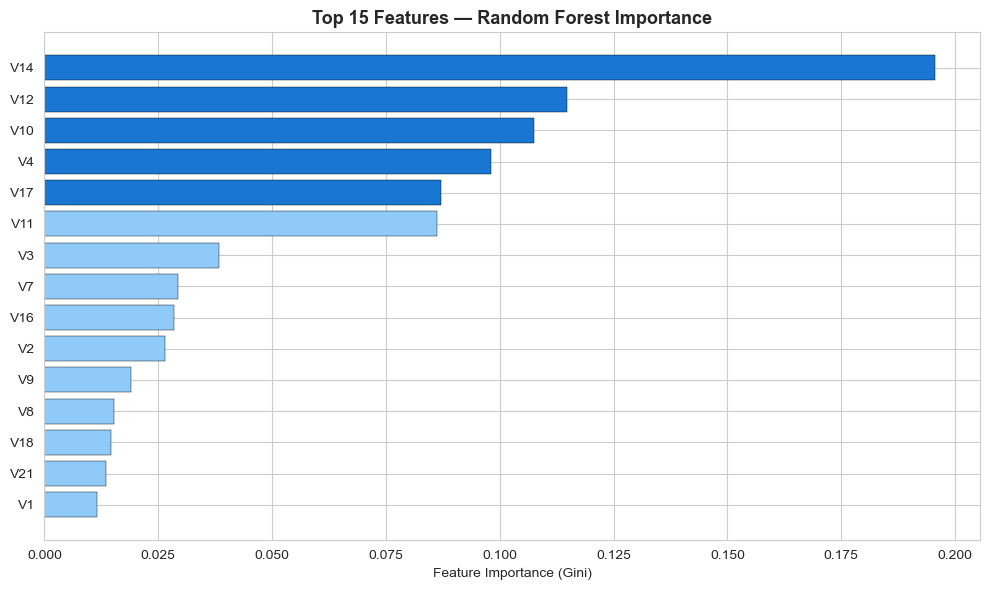

In [7]:
# CELL 7: RANDOM FOREST FEATURE IMPORTANCE

print('=== Random Forest Feature Importance ===')

rf_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(f'Top 10 features by Random Forest importance:')
print(rf_importance.head(10).to_string(index=False))

plt.figure(figsize=(10, 6))
top15_rf = rf_importance.head(15)
colors_rf = ['#1976D2' if i < 5 else '#90CAF9' for i in range(len(top15_rf))]
plt.barh(top15_rf['Feature'][::-1], top15_rf['Importance'][::-1],
         color=colors_rf[::-1], edgecolor='black', linewidth=0.3)
plt.xlabel('Feature Importance (Gini)')
plt.title('Top 15 Features — Random Forest Importance',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# CELL 8: XGBOOST TRAINING

print('   Model 3: XGBoost (Primary/Selected Model)')
print('   Why: Best-in-class for tabular data, handles imbalance,')
print('        SHAP-compatible, fast inference for real-time use')
print('   Algorithm: Gradient Boosted Decision Trees with regularization')
print('-' * 50)

# Scale pos weight: ratio of negative to positive samples
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f'  scale_pos_weight = {scale_pos_weight:.2f} (handles imbalance in XGBoost)')

start = time.time()
xgb_model = xgb.XGBClassifier(
    n_estimators=500,           # Max trees (early stopping controls actual number)
    max_depth=6,                # Depth of each tree
    learning_rate=0.05,         # Shrinkage (lower = more conservative)
    subsample=0.8,              # Row sampling per tree
    colsample_bytree=0.8,       # Feature sampling per tree
    scale_pos_weight=scale_pos_weight,  # Handle imbalance
    reg_alpha=0.1,              # L1 regularization
    reg_lambda=1.0,             # L2 regularization
    eval_metric='aucpr',        # Area under Precision-Recall curve
    early_stopping_rounds=30,   # Stop if no improvement for 30 rounds
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50
)
xgb_time = time.time() - start

print(f'\nTraining time: {xgb_time:.2f}s')
print(f'Best iteration: {xgb_model.best_iteration}')

results['XGBoost'] = evaluate_model(
    xgb_model, X_val, y_val, 'XGBoost'
)

joblib.dump(xgb_model, '../results/model_xgb.pkl')
print('  Model saved: results/model_xgb.pkl')

   Model 3: XGBoost (Primary/Selected Model)
   Why: Best-in-class for tabular data, handles imbalance,
        SHAP-compatible, fast inference for real-time use
   Algorithm: Gradient Boosted Decision Trees with regularization
--------------------------------------------------
  scale_pos_weight = 10.00 (handles imbalance in XGBoost)
[0]	validation_0-aucpr:0.38485
[50]	validation_0-aucpr:0.66553
[100]	validation_0-aucpr:0.73132
[150]	validation_0-aucpr:0.76281
[161]	validation_0-aucpr:0.75854

Training time: 8.41s
Best iteration: 131

═══════════════════════════════════════════════════════
   XGBoost (threshold=0.50)
═══════════════════════════════════════════════════════
  AUC-ROC:            0.9659
  Average Precision:  0.7769
  Precision:          0.3095
  Recall (Sensitivity):0.8228
  F1-Score:           0.4498
  MCC:                0.5034
  Balanced Accuracy:  0.9098
  False Positive Rate:0.0032
  False Negative Rate:0.1772
  Confusion Matrix:
    TN=45,345  FP=145
    FN=14   TP

=== XGBoost Learning Curves ===


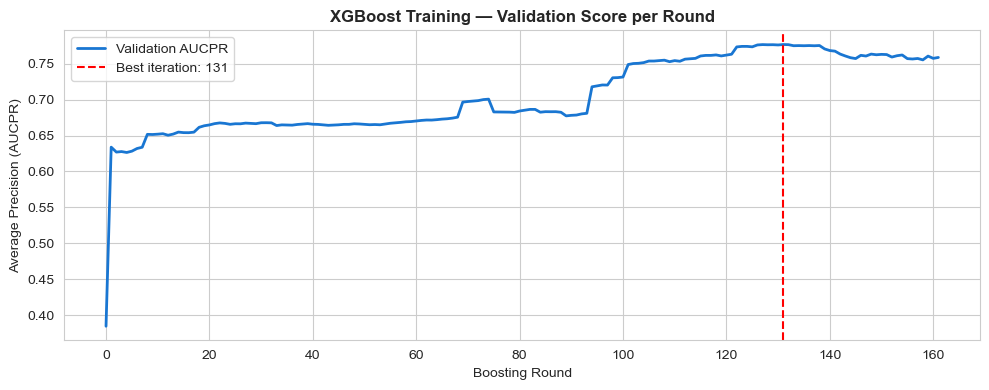

Best validation AUCPR: 0.7765 at round 131


In [9]:
# CELL 9: XGBOOST LEARNING CURVES

print('=== XGBoost Learning Curves ===')

# Training history
evals_result = xgb_model.evals_result()
val_scores = evals_result['validation_0']['aucpr']

plt.figure(figsize=(10, 4))
plt.plot(val_scores, color='#1976D2', linewidth=2, label='Validation AUCPR')
plt.axvline(x=xgb_model.best_iteration, color='red', linestyle='--',
            label=f'Best iteration: {xgb_model.best_iteration}')
plt.xlabel('Boosting Round')
plt.ylabel('Average Precision (AUCPR)')
plt.title('XGBoost Training — Validation Score per Round',
          fontsize=12, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('../results/xgb_learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Best validation AUCPR: {max(val_scores):.4f} at round {xgb_model.best_iteration}')

In [10]:
# CELL 10: HYPERPARAMETER TUNING (GridSearchCV)

print('=== Hyperparameter Tuning: XGBoost ===')
print('Using GridSearchCV with Stratified 3-Fold CV')
print('Scoring: Average Precision (best for imbalanced data)')
print('  This may take a few minutes...')

param_grid = {
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.7, 0.8],
}

xgb_base = xgb.XGBClassifier(
    n_estimators=200,
    scale_pos_weight=scale_pos_weight,
    eval_metric='aucpr',
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

grid_search = GridSearchCV(
    xgb_base, param_grid,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring='average_precision',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f'\n  Best Parameters: {grid_search.best_params_}')
print(f'Best CV Avg Precision: {grid_search.best_score_:.4f}')

# Evaluate tuned model
xgb_tuned = grid_search.best_estimator_
results['XGBoost (Tuned)'] = evaluate_model(
    xgb_tuned, X_val, y_val, 'XGBoost (Tuned)'
)

# Save tuned model
joblib.dump(xgb_tuned, '../results/model_xgb_tuned.pkl')
print('\n  Tuned model saved: results/model_xgb_tuned.pkl')

=== Hyperparameter Tuning: XGBoost ===
Using GridSearchCV with Stratified 3-Fold CV
Scoring: Average Precision (best for imbalanced data)
  This may take a few minutes...
Fitting 3 folds for each of 12 candidates, totalling 36 fits

  Best Parameters: {'learning_rate': 0.1, 'max_depth': 8, 'subsample': 0.7}
Best CV Avg Precision: 0.9999

═══════════════════════════════════════════════════════
   XGBoost (Tuned) (threshold=0.50)
═══════════════════════════════════════════════════════
  AUC-ROC:            0.9611
  Average Precision:  0.8180
  Precision:          0.8158
  Recall (Sensitivity):0.7848
  F1-Score:           0.8000
  MCC:                0.7998
  Balanced Accuracy:  0.8923
  False Positive Rate:0.0003
  False Negative Rate:0.2152
  Confusion Matrix:
    TN=45,476  FP=14
    FN=17   TP=62

  Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     45490
       Fraud       0.82      0.78      0.80        79

 

=== Model Performance Comparison ===
              Model  AUC-ROC  Avg Precision  Precision  Recall  F1-Score    MCC   FP  FN
Logistic Regression   0.9704         0.6822     0.0568  0.8734    0.1066 0.2190 1146  10
      Random Forest   0.9630         0.7862     0.7949  0.7848    0.7898 0.7895   16  17
            XGBoost   0.9659         0.7769     0.3095  0.8228    0.4498 0.5034  145  14
    XGBoost (Tuned)   0.9611         0.8180     0.8158  0.7848    0.8000 0.7998   14  17


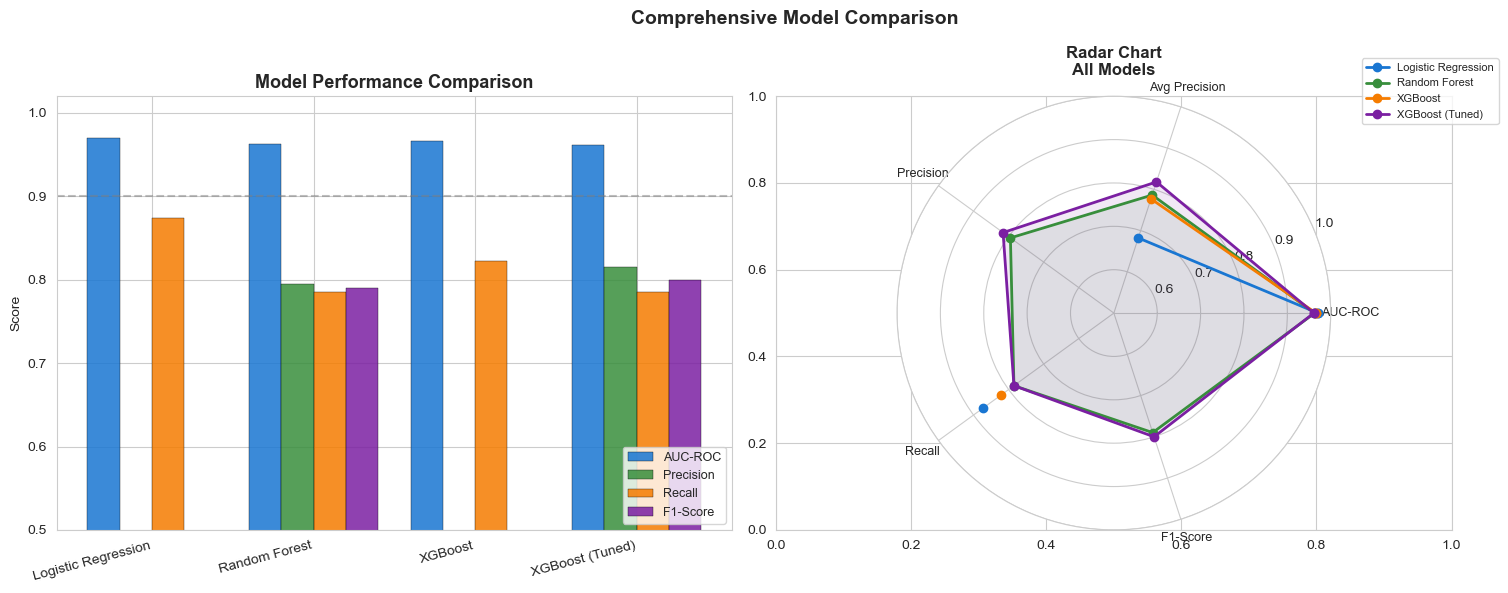


  Best Model by F1-Score: XGBoost (Tuned)


In [11]:
# CELL 11: MODEL COMPARISON TABLE & CHART

print('=== Model Performance Comparison ===')

metrics_df = pd.DataFrame([
    {
        'Model': r['model_name'],
        'AUC-ROC': round(r['auc_roc'], 4),
        'Avg Precision': round(r['avg_precision'], 4),
        'Precision': round(r['precision'], 4),
        'Recall': round(r['recall'], 4),
        'F1-Score': round(r['f1'], 4),
        'MCC': round(r['mcc'], 4),
        'FP': r['fp'],
        'FN': r['fn'],
    }
    for r in results.values()
])
print(metrics_df.to_string(index=False))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart comparison
metric_cols = ['AUC-ROC', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics_df))
width = 0.2
colors_bars = ['#1976D2', '#388E3C', '#F57C00', '#7B1FA2']

for i, (metric, color) in enumerate(zip(metric_cols, colors_bars)):
    axes[0].bar(x + i * width, metrics_df[metric], width,
                label=metric, color=color, alpha=0.85, edgecolor='black', linewidth=0.3)

axes[0].set_xticks(x + width * 1.5)
axes[0].set_xticklabels(metrics_df['Model'], rotation=15, ha='right', fontsize=10)
axes[0].set_ylim(0.5, 1.02)
axes[0].set_ylabel('Score')
axes[0].set_title('Model Performance Comparison',
                  fontsize=13, fontweight='bold')
axes[0].legend(loc='lower right', fontsize=9)
axes[0].axhline(0.9, color='gray', linestyle='--', alpha=0.5)

# Radar chart
categories = ['AUC-ROC', 'Avg Precision', 'Precision', 'Recall', 'F1-Score']
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

ax_radar = plt.subplot(122, projection='polar')
radar_colors = ['#1976D2', '#388E3C', '#F57C00', '#7B1FA2']

for idx, (_, row) in enumerate(metrics_df.iterrows()):
    values = [row[c] for c in categories]
    values += values[:1]
    ax_radar.plot(angles, values, 'o-', linewidth=2,
                  color=radar_colors[idx % len(radar_colors)],
                  label=row['Model'])
    ax_radar.fill(angles, values, alpha=0.1,
                  color=radar_colors[idx % len(radar_colors)])

ax_radar.set_xticks(angles[:-1])
ax_radar.set_xticklabels(categories, size=9)
ax_radar.set_ylim(0.5, 1.0)
ax_radar.set_title('Radar Chart\nAll Models', fontsize=12, fontweight='bold', pad=15)
ax_radar.legend(loc='upper right', bbox_to_anchor=(1.4, 1.1), fontsize=8)

plt.suptitle('Comprehensive Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

best_model_name = metrics_df.loc[metrics_df['F1-Score'].idxmax(), 'Model']
print(f'\n  Best Model by F1-Score: {best_model_name}')

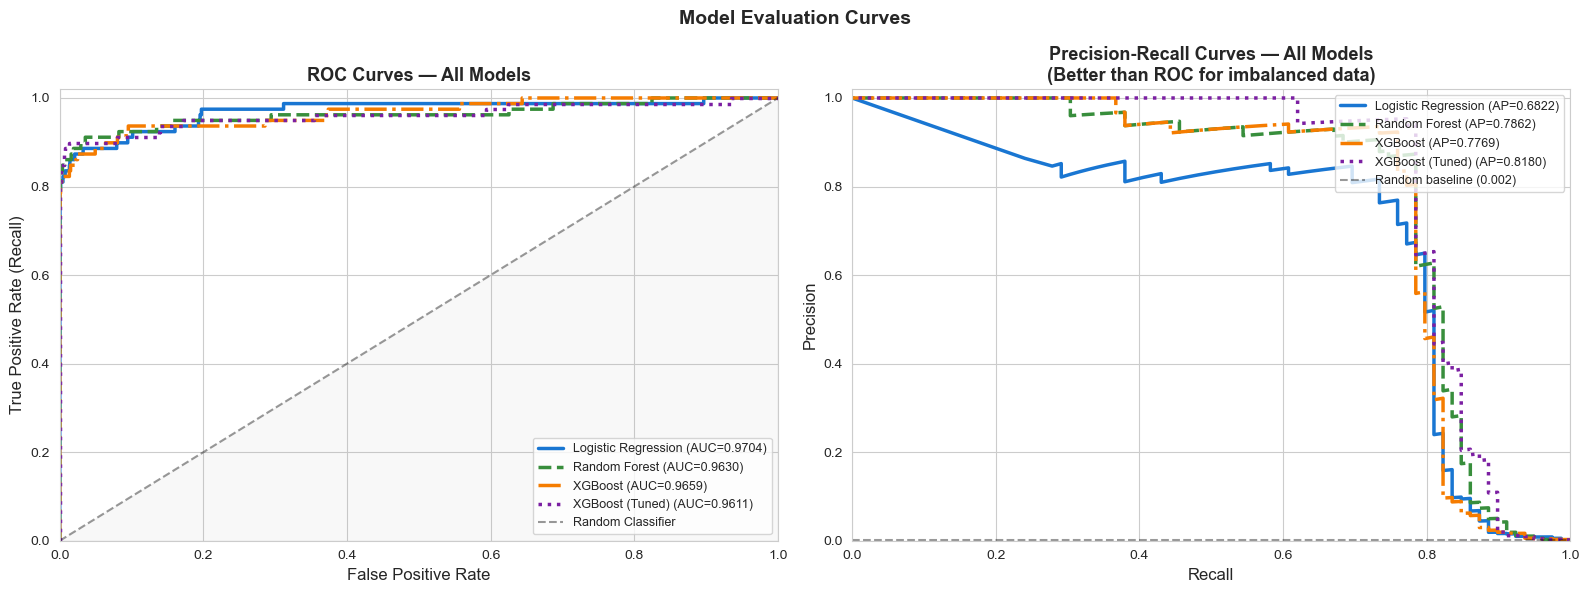

  Saved: results/roc_curves.png


In [12]:
# CELL 12: ROC & PR CURVES

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plot_colors = ['#1976D2', '#388E3C', '#F57C00', '#7B1FA2']
line_styles = ['-', '--', '-.', ':']

for (name, r), color, ls in zip(results.items(), plot_colors, line_styles):
    # ROC Curve
    fpr_c, tpr_c, _ = roc_curve(y_val, r['y_prob'])
    axes[0].plot(fpr_c, tpr_c, color=color, lw=2.5, linestyle=ls,
                 label=f"{name} (AUC={r['auc_roc']:.4f})")

    # Precision-Recall Curve
    prec_c, rec_c, _ = precision_recall_curve(y_val, r['y_prob'])
    axes[1].plot(rec_c, prec_c, color=color, lw=2.5, linestyle=ls,
                 label=f"{name} (AP={r['avg_precision']:.4f})")

# ROC plot formatting
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random Classifier')
axes[0].fill_between([0, 1], [0, 1], alpha=0.05, color='gray')
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate (Recall)', fontsize=12)
axes[0].set_title('ROC Curves — All Models', fontsize=13, fontweight='bold')
axes[0].legend(loc='lower right', fontsize=9)
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1.02])

# PR plot formatting
baseline_pr = y_val.mean()
axes[1].axhline(baseline_pr, color='k', linestyle='--', alpha=0.4,
               label=f'Random baseline ({baseline_pr:.3f})')
axes[1].set_xlabel('Recall', fontsize=12)
axes[1].set_ylabel('Precision', fontsize=12)
axes[1].set_title('Precision-Recall Curves — All Models\n(Better than ROC for imbalanced data)',
                  fontsize=13, fontweight='bold')
axes[1].legend(loc='upper right', fontsize=9)
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.02])

plt.suptitle('Model Evaluation Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('  Saved: results/roc_curves.png')

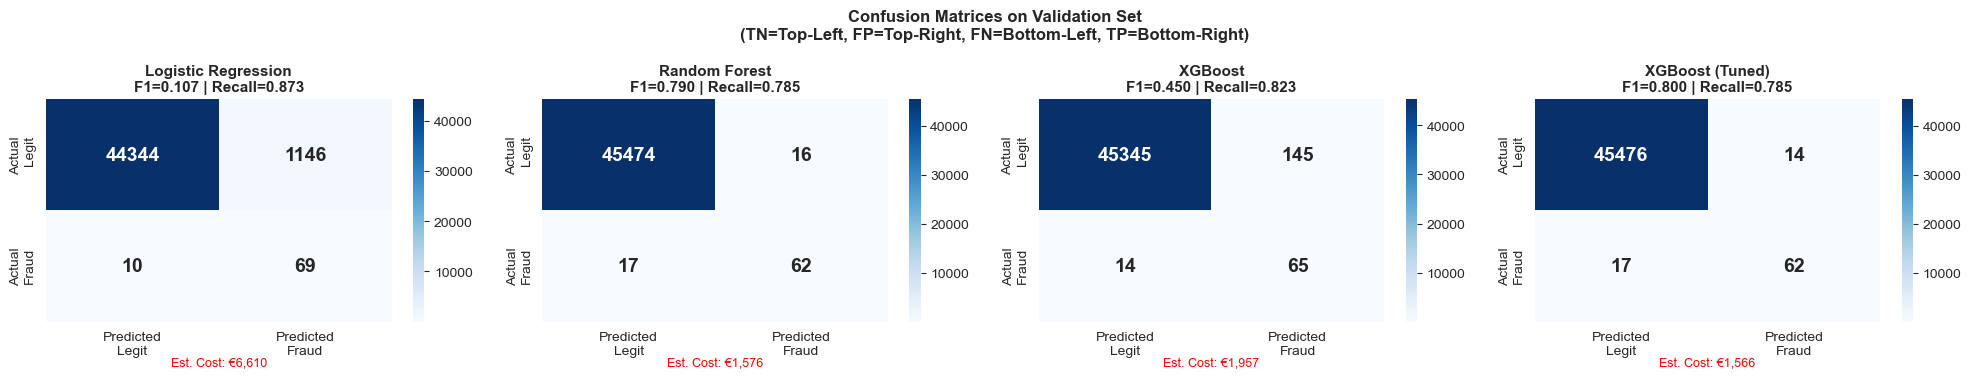

   FN = Missed fraud (costly!) | FP = Blocked legit customer (annoying)
   XGBoost minimizes FN → best for fraud detection!


In [13]:
# CELL 13: CONFUSION MATRICES

n_models = len(results)
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 4))

if n_models == 1:
    axes = [axes]

for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(y_val, r['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                cmap='Blues',
                xticklabels=['Predicted\nLegit', 'Predicted\nFraud'],
                yticklabels=['Actual\nLegit', 'Actual\nFraud'],
                annot_kws={'size': 14, 'weight': 'bold'})
    tn, fp, fn, tp = cm.ravel()
    ax.set_title(f'{name}\nF1={r["f1"]:.3f} | Recall={r["recall"]:.3f}',
                 fontsize=11, fontweight='bold')

    # Add cost annotation
    cost = fn * 88 + fp * 5  # FN costs more!
    ax.text(1, 2.4, f'Est. Cost: €{cost:,.0f}',
            ha='center', fontsize=9, color='red',
            transform=ax.transData)

plt.suptitle('Confusion Matrices on Validation Set\n(TN=Top-Left, FP=Top-Right, FN=Bottom-Left, TP=Bottom-Right)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

print('   FN = Missed fraud (costly!) | FP = Blocked legit customer (annoying)')
print('   XGBoost minimizes FN → best for fraud detection!')

   SHAP Explainability Analysis
   Why SHAP? Required by regulators (GDPR Art.22, Basel III)
   Explains WHY the model flagged a transaction as fraud
   Uses TreeExplainer — exact SHAP for tree-based models
--------------------------------------------------
SHAP values computed for 500 samples
SHAP matrix shape: (500, 32)


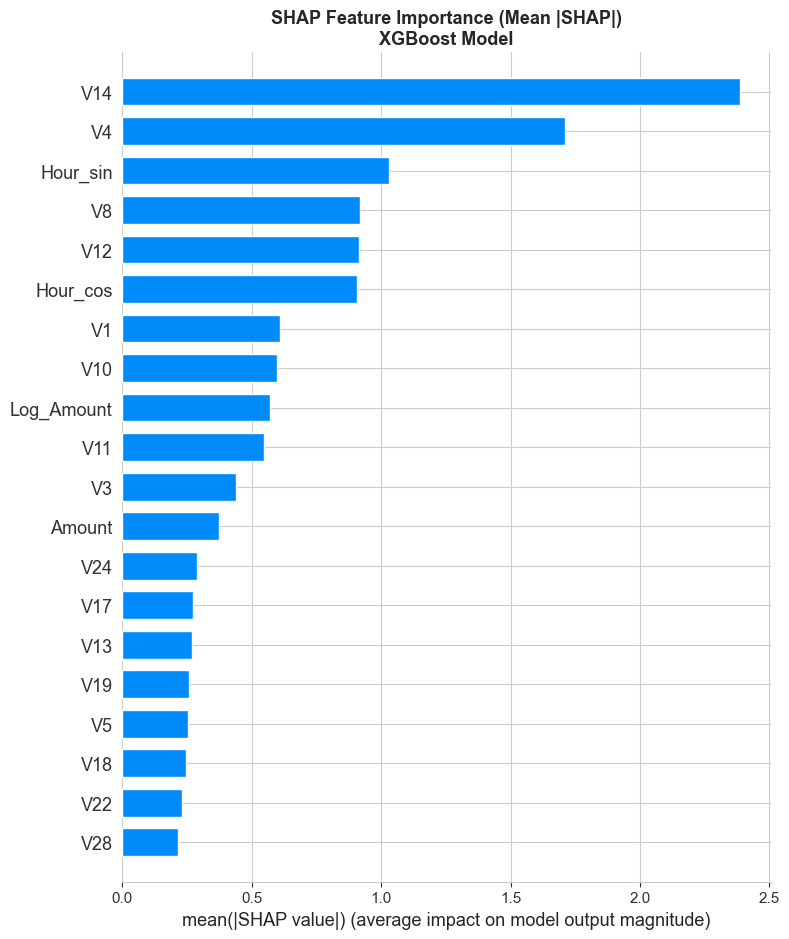

  Saved: results/shap_importance.png


In [14]:
# CELL 14: SHAP VALUES — GLOBAL EXPLAINABILITY

print('   SHAP Explainability Analysis')
print('   Why SHAP? Required by regulators (GDPR Art.22, Basel III)')
print('   Explains WHY the model flagged a transaction as fraud')
print('   Uses TreeExplainer — exact SHAP for tree-based models')
print('-' * 50)

# Sample for speed (SHAP is slow on full dataset)
np.random.seed(42)
sample_idx = np.random.choice(len(X_val), min(500, len(X_val)), replace=False)
X_val_sample = X_val[sample_idx]
y_val_sample = y_val[sample_idx]

# Use best model (tuned XGBoost if available, else base)
best_xgb = xgb_tuned if 'XGBoost (Tuned)' in results else xgb_model

explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_val_sample)

print(f'SHAP values computed for {len(X_val_sample)} samples')
print(f'SHAP matrix shape: {shap_values.shape}')

# SHAP Summary Plot (Bar — Global Importance)
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, X_val_sample,
    feature_names=feature_names,
    plot_type='bar',
    max_display=20,
    show=False
)
plt.title('SHAP Feature Importance (Mean |SHAP|)\nXGBoost Model',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('  Saved: results/shap_importance.png')

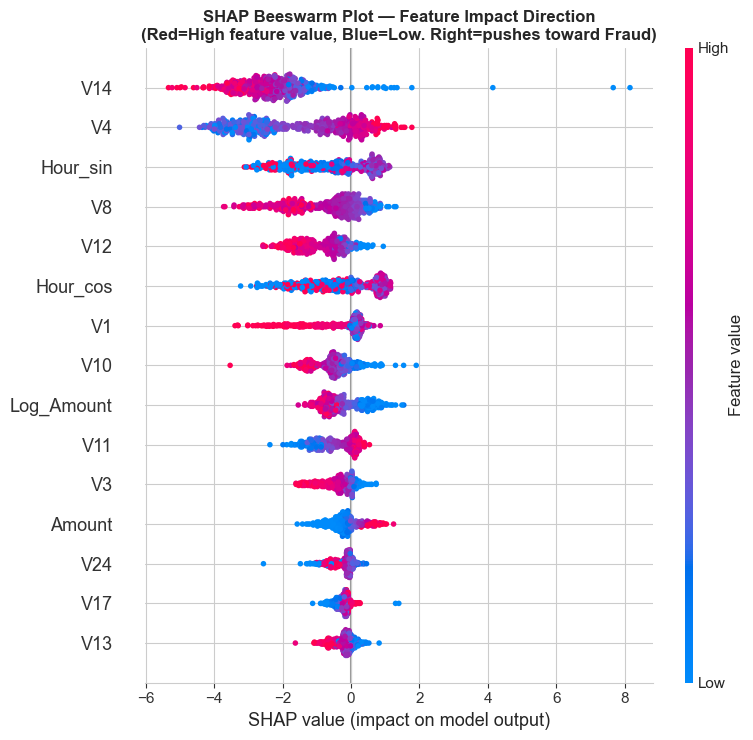

  Saved: results/shap_summary.png

  How to read: Dots right of center = pushes model toward FRAUD prediction


In [16]:
# CELL 15: SHAP BEESWARM PLOT (Feature Direction)

plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, X_val_sample,
    feature_names=feature_names,
    max_display=15,
    show=False
)
plt.title('SHAP Beeswarm Plot — Feature Impact Direction\n'
          '(Red=High feature value, Blue=Low. Right=pushes toward Fraud)',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('  Saved: results/shap_summary.png')
print('\n  How to read: Dots right of center = pushes model toward FRAUD prediction')

=== SHAP: Explaining a Single Fraud Transaction ===
Transaction index: 91
True label: FRAUD
Model prediction: 100.0% fraud probability


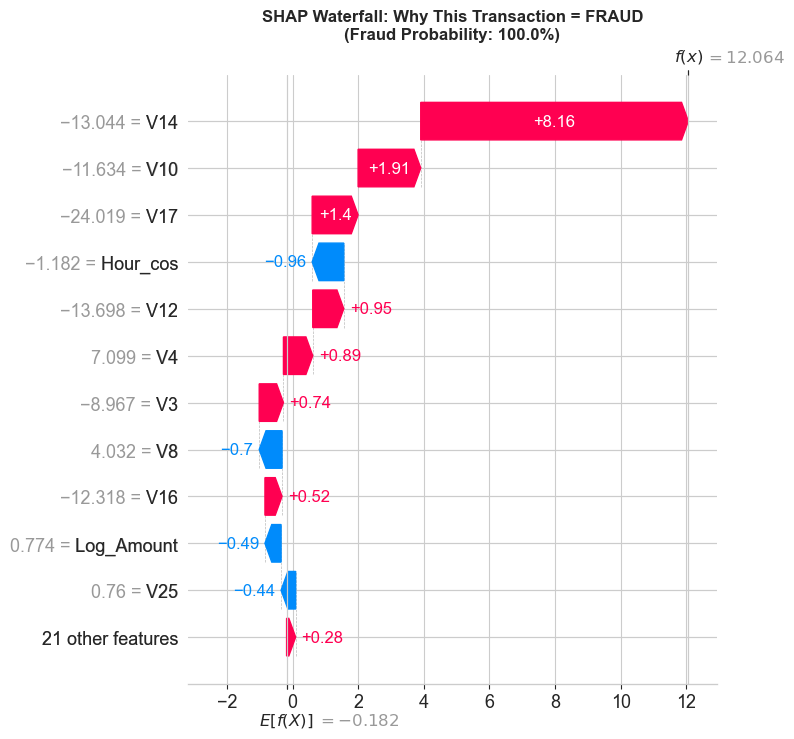

  Saved: results/shap_waterfall.png

  Waterfall shows each feature's contribution to the final fraud score


In [17]:
# CELL 16: SHAP — SINGLE TRANSACTION EXPLANATION

print('=== SHAP: Explaining a Single Fraud Transaction ===')

# Find a fraud transaction in validation set
fraud_indices = np.where(y_val_sample == 1)[0]

if len(fraud_indices) > 0:
    fraud_idx = fraud_indices[0]
    fraud_prob = best_xgb.predict_proba(X_val_sample[fraud_idx:fraud_idx+1])[0][1]

    print(f'Transaction index: {fraud_idx}')
    print(f'True label: FRAUD')
    print(f'Model prediction: {fraud_prob*100:.1f}% fraud probability')

    # Waterfall plot
    shap_explanation = shap.Explanation(
        values=shap_values[fraud_idx],
        base_values=explainer.expected_value,
        data=X_val_sample[fraud_idx],
        feature_names=feature_names
    )

    plt.figure(figsize=(10, 6))
    shap.waterfall_plot(shap_explanation, max_display=12, show=False)
    plt.title(f'SHAP Waterfall: Why This Transaction = FRAUD\n'
              f'(Fraud Probability: {fraud_prob*100:.1f}%)',
              fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../results/shap_waterfall.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('  Saved: results/shap_waterfall.png')
    print('\n  Waterfall shows each feature\'s contribution to the final fraud score')
else:
    print('No fraud samples in this validation sample — increase sample size')

=== Business Cost-Based Threshold Optimization ===

Business assumptions:
  FP (False Positive) cost = €5   (customer friction, support call)
  FN (False Negative) cost = €88  (avg fraud amount lost)
  FN costs 17.6x more than FP → optimize threshold lower!

Optimal threshold (cost-based): 0.11
Minimum business cost:          €1,500


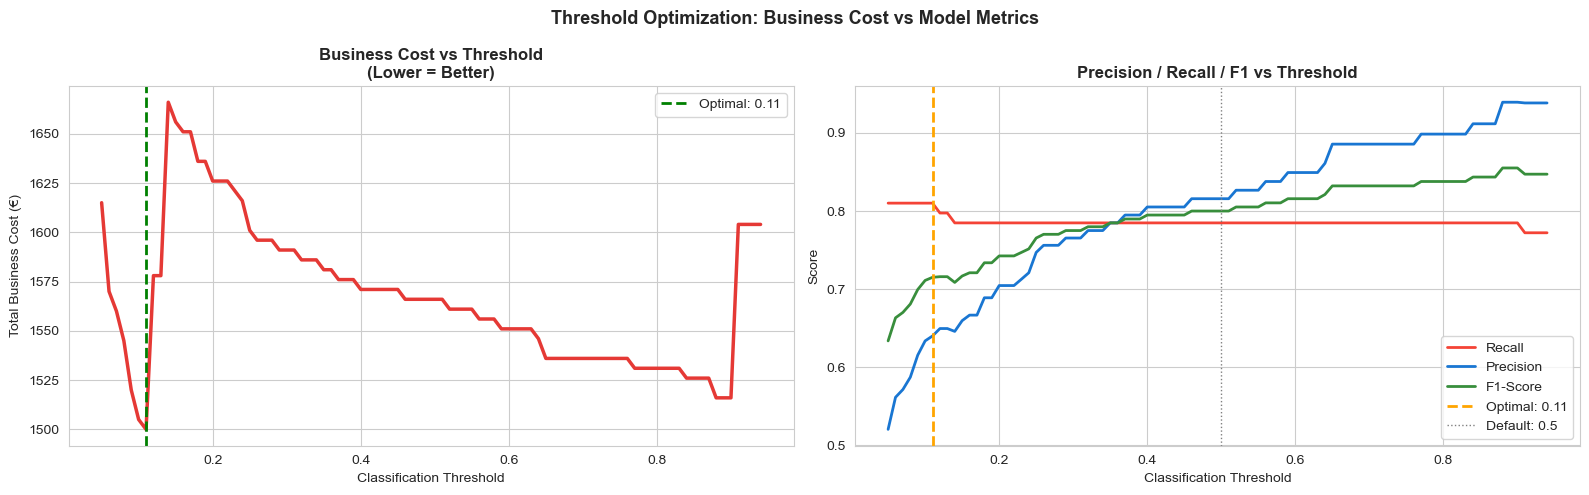


=== Model Performance at Optimal Threshold (0.11) ===

═══════════════════════════════════════════════════════
   XGBoost (Optimal Threshold) (threshold=0.11)
═══════════════════════════════════════════════════════
  AUC-ROC:            0.9611
  Average Precision:  0.8180
  Precision:          0.6400
  Recall (Sensitivity):0.8101
  F1-Score:           0.7151
  MCC:                0.7195
  Balanced Accuracy:  0.9047
  False Positive Rate:0.0008
  False Negative Rate:0.1899
  Confusion Matrix:
    TN=45,454  FP=36
    FN=15   TP=64

  Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     45490
       Fraud       0.64      0.81      0.72        79

    accuracy                           1.00     45569
   macro avg       0.82      0.90      0.86     45569
weighted avg       1.00      1.00      1.00     45569



In [18]:
# CELL 17: THRESHOLD OPTIMIZATION

print('=== Business Cost-Based Threshold Optimization ===')
print('''
Business assumptions:
  FP (False Positive) cost = €5   (customer friction, support call)
  FN (False Negative) cost = €88  (avg fraud amount lost)
  FN costs 17.6x more than FP → optimize threshold lower!
''')

# Use best XGBoost model
val_probs = best_xgb.predict_proba(X_val)[:, 1]

FP_COST = 5
FN_COST = 88

thresholds = np.arange(0.05, 0.95, 0.01)
total_costs, f1_scores, precisions, recalls = [], [], [], []

for t in thresholds:
    y_pred_t = (val_probs >= t).astype(int)
    cm = confusion_matrix(y_val, y_pred_t)
    tn, fp, fn, tp = cm.ravel()
    cost = fp * FP_COST + fn * FN_COST
    total_costs.append(cost)
    f1_scores.append(f1_score(y_val, y_pred_t, zero_division=0))
    precisions.append(precision_score(y_val, y_pred_t, zero_division=0))
    recalls.append(recall_score(y_val, y_pred_t, zero_division=0))

optimal_idx = np.argmin(total_costs)
optimal_threshold = thresholds[optimal_idx]
optimal_cost = total_costs[optimal_idx]

print(f'Optimal threshold (cost-based): {optimal_threshold:.2f}')
print(f'Minimum business cost:          €{optimal_cost:,.0f}')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(thresholds, total_costs, color='#E53935', linewidth=2.5)
axes[0].axvline(optimal_threshold, color='green', linestyle='--', linewidth=2,
               label=f'Optimal: {optimal_threshold:.2f}')
axes[0].set_xlabel('Classification Threshold')
axes[0].set_ylabel('Total Business Cost (€)')
axes[0].set_title('Business Cost vs Threshold\n(Lower = Better)',
                  fontsize=12, fontweight='bold')
axes[0].legend()

axes[1].plot(thresholds, recalls, color='#F44336', linewidth=2, label='Recall')
axes[1].plot(thresholds, precisions, color='#1976D2', linewidth=2, label='Precision')
axes[1].plot(thresholds, f1_scores, color='#388E3C', linewidth=2, label='F1-Score')
axes[1].axvline(optimal_threshold, color='orange', linestyle='--', linewidth=2,
               label=f'Optimal: {optimal_threshold:.2f}')
axes[1].axvline(0.5, color='gray', linestyle=':', linewidth=1, label='Default: 0.5')
axes[1].set_xlabel('Classification Threshold')
axes[1].set_ylabel('Score')
axes[1].set_title('Precision / Recall / F1 vs Threshold',
                  fontsize=12, fontweight='bold')
axes[1].legend()

plt.suptitle('Threshold Optimization: Business Cost vs Model Metrics',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/threshold_optimization.png', dpi=150, bbox_inches='tight')
plt.show()

# Evaluate at optimal threshold
print(f'\n=== Model Performance at Optimal Threshold ({optimal_threshold:.2f}) ===')
results['XGBoost (Optimal Threshold)'] = evaluate_model(
    best_xgb, X_val, y_val,
    'XGBoost (Optimal Threshold)',
    threshold=optimal_threshold
)